In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
from matplotlib.patches import Patch

# Setting up the plot styles
plt.style.use(['seaborn-v0_8-white', 'seaborn-v0_8-paper'])
plt.rc('font', family='serif')
sns.set_palette('Set1')
sns.set_context('paper', font_scale=1.3)    # single-column figure

## Public SNE clones and their p-value rank

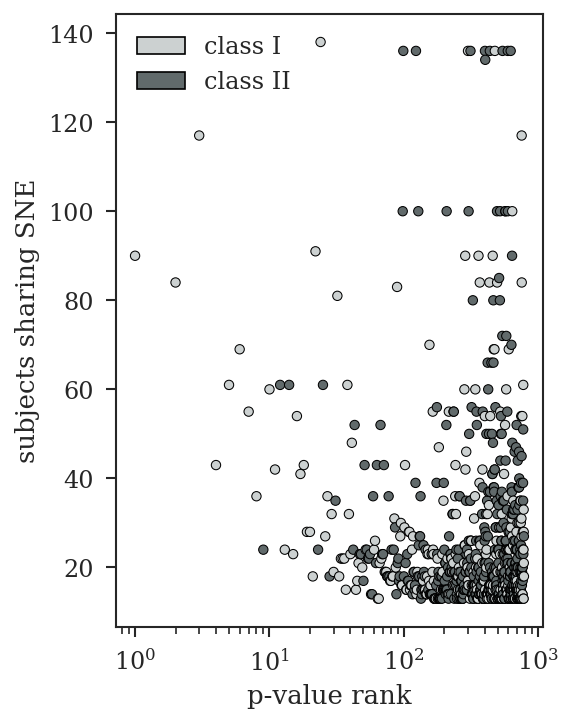

In [4]:
hla = pd.read_table('./phd/repositories/sne_manuscript/analysis/emerson/hla_association_updated.txt')
hla = hla[hla.pval_adj<.05]

colors = {
    'class I':'#ccd1d1',
    'class II':'#616a6b',
}

x = hla.pval_rank
y = hla.occurrence
c = hla.hla_class.map(colors)

fig, ax = plt.subplots(dpi=150, figsize=(4,5))
ax.scatter(x,y,s=20,c=c,edgecolors='k',linewidths=.5)
ax.set_xscale('log')

ax.set_xlabel('p-value rank')
ax.set_ylabel('subjects sharing SNE')

legend_elements = [
    Patch(facecolor=colors['class I'], edgecolor='k', label='class I'),
    Patch(facecolor=colors['class II'], edgecolor='k', label='class II')
    ]

ax.legend(handles=legend_elements)

fig.tight_layout()
fig.savefig('./phd/repositories/sne_manuscript/fig/hla_association_pvalrank.png', dpi=500, bbox_inches='tight', format='png')

## HLA association of SNE clones

/tmp/ipykernel_75379/1852499000.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


[Text(0, 0, 'class II'), Text(1, 0, 'class I')]

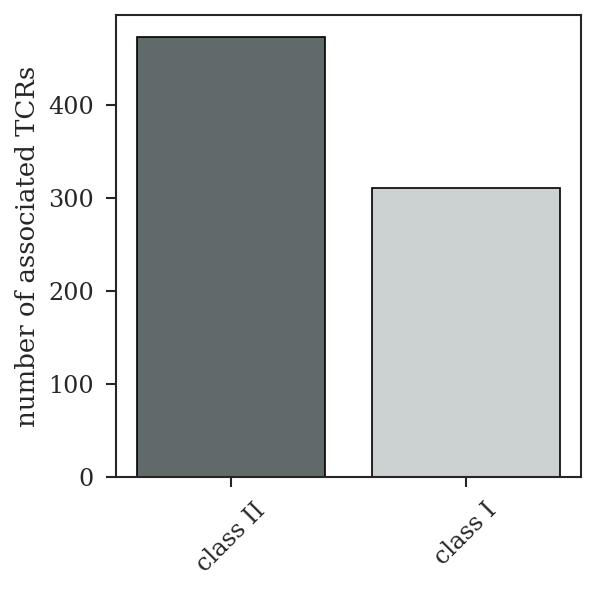

In [5]:
fig, ax = plt.subplots(dpi=150, figsize=(4,4))

data = hla.hla_class.value_counts()
ax.bar(height=data.values, x=data.index, color=[colors[x] for x in data.index], edgecolor='k')
ax.set_ylabel('number of associated TCRs')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

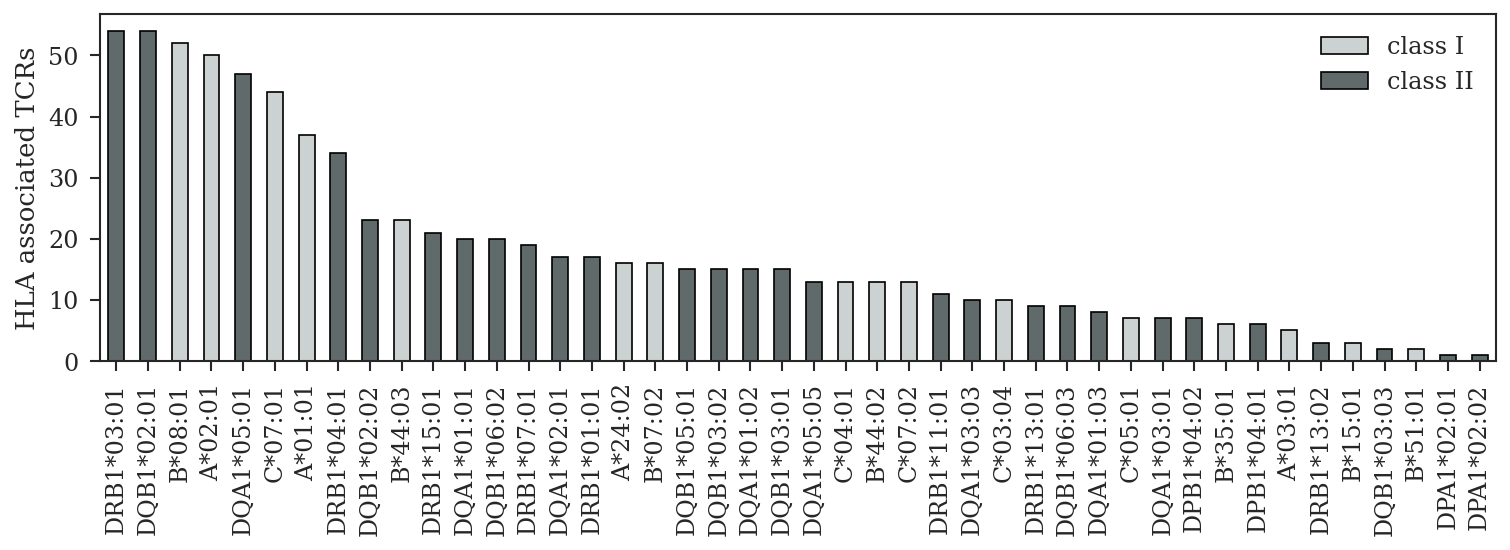

In [6]:
fig, ax = plt.subplots(dpi=150, figsize=(12,3))
alleles = hla.allele.value_counts().index
hla_class = ['class II' if 'D' in i else 'class I' for i in list(alleles)]
hla.allele.value_counts().plot(kind='bar', color=[colors[x] for x in hla_class], edgecolor='k', ax=ax)
ax.set_ylabel('HLA associated TCRs')
ax.set_xlabel('')

legend_elements = [
    Patch(facecolor=colors['class I'], edgecolor='k', label='class I'),
    Patch(facecolor=colors['class II'], edgecolor='k', label='class II')
    ]

ax.legend(handles=legend_elements, loc='upper right')
fig.savefig('./phd/repositories/sne_manuscript/fig/hla_association_counts.png', dpi=500, bbox_inches='tight', format='png')

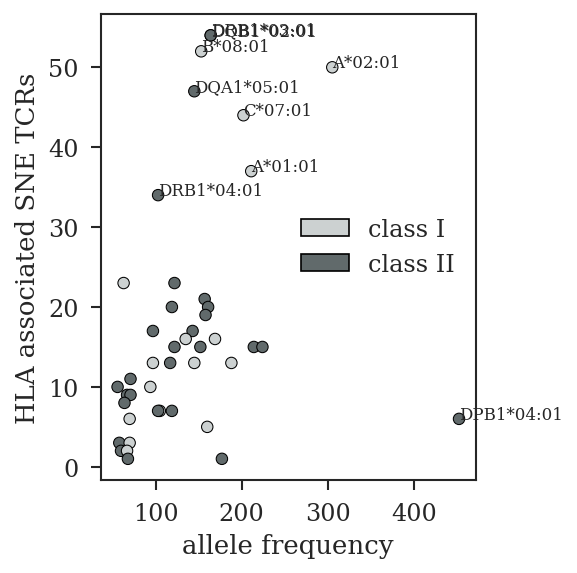

In [10]:
hla_info = pd.read_table('./phd/repositories/sne_manuscript/data/emerson/newest_hla_info_df.tsv')
allele_frequency = {}

for hipid in hla_info.hipid:
    sub = hla_info[hla_info.hipid==hipid]
    present = sub.values.tolist()[0][1:]
    for i in present:
        if i not in allele_frequency:
            allele_frequency[i] = 1
        else:
            allele_frequency[i] += 1

hla_classification = dict(zip(hla.allele, hla.hla_class))
allele_count = pd.DataFrame(hla.allele.value_counts()).reset_index()
allele_count['hla_class'] = allele_count.allele.map(hla_classification)

fig, ax = plt.subplots(dpi=150, figsize=(4,4))

allele_count['allele_frequency'] = allele_count.allele.map(allele_frequency)
ax.scatter(
    allele_count['allele_frequency'], allele_count['count'], 
    c=[colors[x] for x in allele_count['hla_class']], edgecolor='k', linewidths=.5,
    s=30
    )

legend_elements = [
    Patch(facecolor=colors['class I'], edgecolor='k', label='class I'),
    Patch(facecolor=colors['class II'], edgecolor='k', label='class II')
    ]

ax.legend(handles=legend_elements)
ax.set_xlabel('allele frequency')
ax.set_ylabel('HLA associated SNE TCRs')

ycutoff = 30
xcutoff = 300

for _, i in allele_count.iterrows():
    if i['allele_frequency'] > xcutoff or i['count'] > ycutoff:
        ax.text(i['allele_frequency'], i['count'], i['allele'], fontsize=8) 

allele_count.head()
fig.tight_layout()

fig.savefig('./phd/repositories/sne_manuscript/fig/hla_association_frequency.png', dpi=500, bbox_inches='tight', format='png')

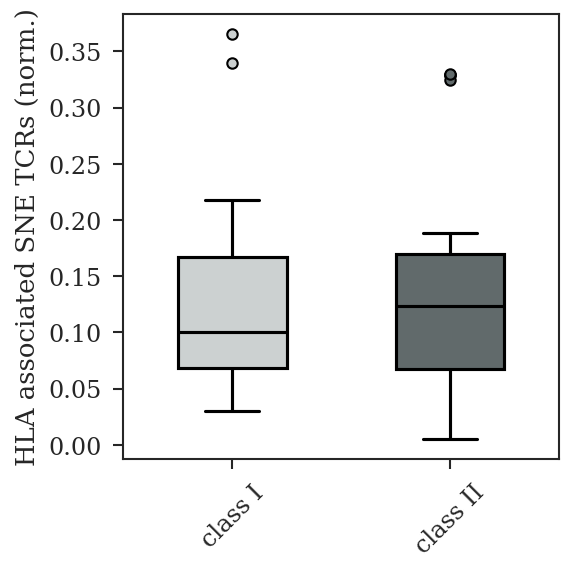

In [11]:
allele_count['normalized_count'] = allele_count['count'] / allele_count['allele_frequency']

fig, ax = plt.subplots(dpi=150, figsize=(4,4))

a = allele_count[allele_count.hla_class=='class I'].normalized_count
b = allele_count[allele_count.hla_class=='class II'].normalized_count

boxprops_1 = dict(linestyle='-', linewidth=1.5, facecolor=colors['class I'])
boxprops_2 = dict(linestyle='-', linewidth=1.5, facecolor=colors['class II'])
medianprops = dict(linestyle='-', linewidth=1.5, color='k')
flierprops_1 = dict(marker='o', markerfacecolor=colors['class I'], markersize=5, linestyle='none')
flierprops_2 = dict(marker='o', markerfacecolor=colors['class II'], markersize=5, linestyle='none')
capprops = dict(linestyle='-', linewidth=1.5)
whiskerprops = dict(linestyle='-', linewidth=1.5)
ax.boxplot(a, positions=[0], boxprops=boxprops_1, medianprops=medianprops, flierprops=flierprops_1, capprops=capprops, whiskerprops=whiskerprops, patch_artist=True, vert=True, widths=.5)
ax.boxplot(b, positions=[1], boxprops=boxprops_2, medianprops=medianprops, flierprops=flierprops_2, capprops=capprops, whiskerprops=whiskerprops, patch_artist=True, vert=True, widths=.5)

from scipy.stats import mannwhitneyu
mannwhitneyu(a,b)

ax.set_xticklabels(['class I', 'class II'], rotation=45)
ax.set_ylabel('HLA associated SNE TCRs (norm.)')

fig.tight_layout()
fig.savefig('./phd/repositories/sne_manuscript/fig/hla_association_classIvsII.png', dpi=500, bbox_inches='tight', format='png')

/tmp/ipykernel_75379/1815927957.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='hla_class', y='normalized_count', data=allele_count, ax=ax, palette=colors)
/tmp/ipykernel_75379/1815927957.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['class I', 'class II'], rotation=45)


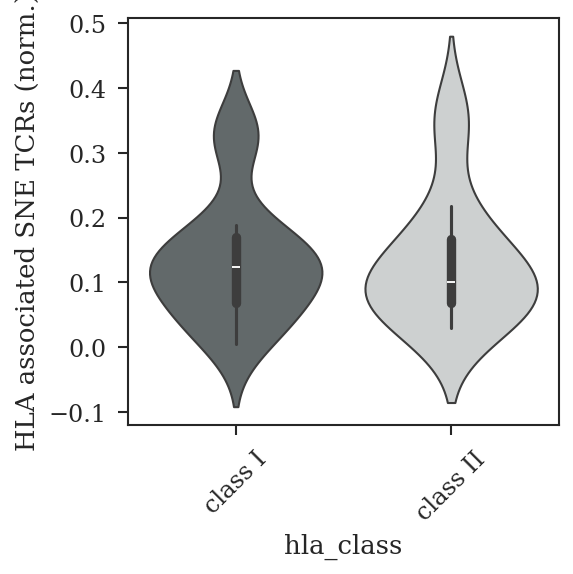

In [12]:
allele_count['normalized_count'] = allele_count['count'] / allele_count['allele_frequency']

fig, ax = plt.subplots(dpi=150, figsize=(4,4))

sns.violinplot(x='hla_class', y='normalized_count', data=allele_count, ax=ax, palette=colors)

mannwhitneyu(a,b)

ax.set_xticklabels(['class I', 'class II'], rotation=45)
ax.set_ylabel('HLA associated SNE TCRs (norm.)')

fig.tight_layout()
# fig.savefig('./phd/repositories/sne_manuscript/fig/hla_association_classIvsII.png', dpi=500, bbox_inches='tight', format='png')

### Comparing HLA-associated SNE clones with HLA-associated clones from DeWitt et al.
10.7554/eLife.38358

In [14]:
dewitt = pd.read_table('./phd/repositories/sne_manuscript/analysis/emerson/dewitt_tcrs.tsv',sep='\t')
dewitt[['v','cdr3']] = dewitt.tcr.str.split(',',expand=True)

def parse_dewitt_vgenes(v):

    if v[1] == '0':
        return f'TRBV{v[2]}'
    else:
        return f'TRBV{v[1:]}'

dewitt['vfam'] = dewitt.v.apply(parse_dewitt_vgenes)
dewitt['clone_vfam'] = dewitt['vfam'] + '_' + dewitt['cdr3']

hla[['v_call','junction_aa']] = hla.tcr.str.split('_', expand=True)
hla['vfam'] = hla.v_call.apply(lambda x: x.split('*')[0].split('-')[0])
hla['clone_vfam'] = hla['vfam'] + '_' + hla['junction_aa']

sne_hla = set(hla.clone_vfam)
dewitt_hla = set(dewitt.clone_vfam)
inter = sne_hla.intersection(dewitt_hla)

print(len(sne_hla)-len(inter), len(dewitt_hla)-len(inter), len(inter))

148 16796 155


#### Number of individuals sharing clone (occurrence) 

/home/sebastiaan/miniconda3/envs/sne_test/lib/python3.9/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


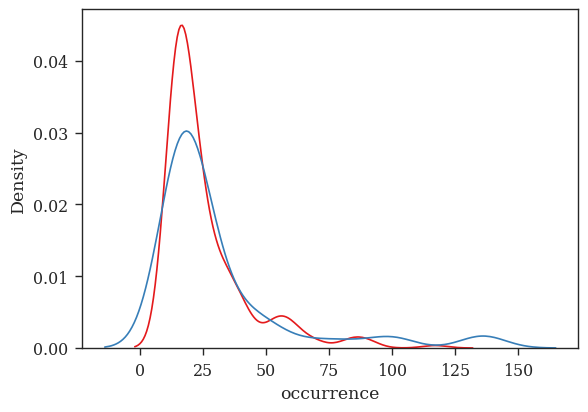

In [15]:
hla['dewitt'] = [True if i in inter else False for i in hla.clone_vfam]

sns.kdeplot(hla[hla.dewitt==True].occurrence)
sns.kdeplot(hla[hla.dewitt==False].occurrence)

from clustcrdist.constants.modules.olga import load_model
from clustcrdist.constants.modules.olga import generation_probability as pgen
from clustcrdist.constants.modules.olga import sequence_generation as seq_gen

import numpy as np

params_file_name = "./phd/repositories/immune_response_detection/clustcrdist/constants/modules/olga/default_models/human_T_beta/model_params.txt"
marginals_file_name = "./phd/repositories/immune_response_detection/clustcrdist/constants/modules/olga/default_models/human_T_beta/model_marginals.txt"
V_anchor_pos_file = "./phd/repositories/immune_response_detection/clustcrdist/constants/modules/olga/default_models/human_T_beta/V_gene_CDR3_anchors.csv"
J_anchor_pos_file = "./phd/repositories/immune_response_detection/clustcrdist/constants/modules/olga/default_models/human_T_beta/J_gene_CDR3_anchors.csv"

genomic_data = load_model.GenomicDataVDJ()
genomic_data.load_igor_genomic_data(params_file_name,V_anchor_pos_file,J_anchor_pos_file)

generative_model = load_model.GenerativeModelVDJ()
generative_model.load_and_process_igor_model(marginals_file_name)

pgen_model = pgen.GenerationProbabilityVDJ(generative_model,genomic_data)

np.random.seed(42)

def get_pgen(tcr):
    v, cdr3 = tcr
    prob = pgen_model.compute_aa_CDR3_pgen(CDR3_seq=cdr3,V_usage_mask_in=v)
    return prob

def match_pgen_distribution(sample, population, n):

    bins = round(n/2)
    hist, bin_edges = np.histogram(sample.log_pgen, bins=bins)
    categories = [(bin_edges[i], bin_edges[i + 1]) for i in range(len(bin_edges) - 1)]

    to_sample = dict(zip(categories, hist))

    pgen_matched = []
    for boundaries in to_sample:
        n = to_sample[boundaries]
        lower, upper = boundaries
        sub = population[population.log_pgen<=upper]
        sub = sub[sub.log_pgen>=lower]
        sampled = sub.sample(n)
        pgen_matched.append(sampled)
        
    return pd.concat(pgen_matched)

hla['pgen'] = [get_pgen(i.split('_')) for i in hla.tcr]

/tmp/ipykernel_75379/3411673727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=hla, x='dewitt', y='occurrence', ax=ax, palette=['#ccd1d1', '#616a6b'], cut=1)
/tmp/ipykernel_75379/3411673727.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Unique', 'Overlapping'], rotation=45)


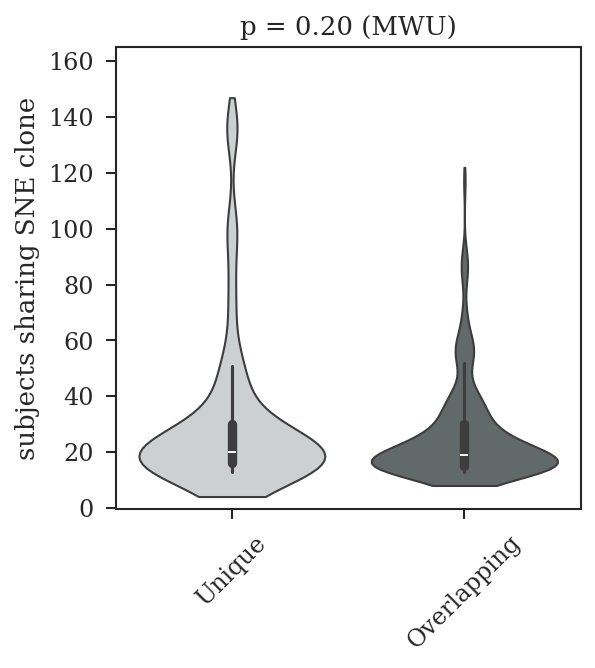

In [21]:
fig, ax = plt.subplots(dpi=150, figsize=(4,4))

sns.violinplot(data=hla, x='dewitt', y='occurrence', ax=ax, palette=['#ccd1d1', '#616a6b'], cut=1)
S, p = mannwhitneyu(hla[hla.dewitt==True].occurrence, hla[hla.dewitt==False].occurrence)

ax.set_xlabel('')
ax.set_ylabel('subjects sharing SNE clone')

ax.set_xticklabels(['Unique', 'Overlapping'], rotation=45)
ax.set_title(f'p = {p:.2f} (MWU)')
ax.set_ylim(-.5,165)

fig.savefig('./phd/repositories/sne_manuscript/fig/dewitt_ovl_occurr.png', dpi=500, bbox_inches='tight', format='png')

#### Pgen distribution 

/home/sebastiaan/miniconda3/envs/sne_test/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='logpgen', ylabel='Density'>

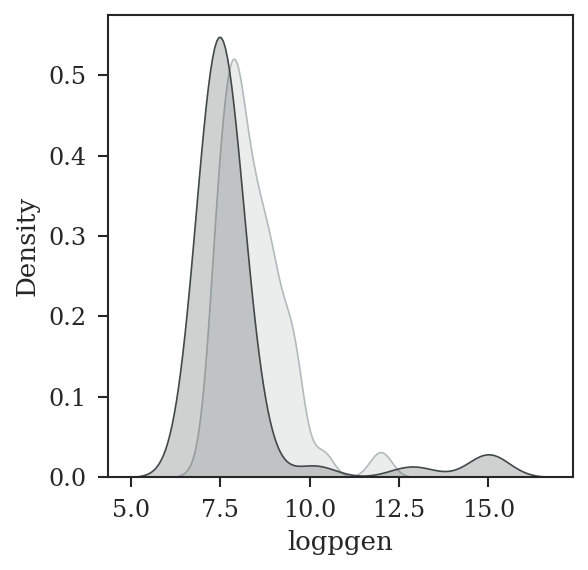

In [17]:
hla['logpgen'] = -np.log10(hla.pgen)

fig, ax = plt.subplots(dpi=150, figsize=(4,4))

sns.kdeplot(hla[hla.dewitt==True].logpgen, ax=ax, color='#b2babb', fill=True)
sns.kdeplot(hla[hla.dewitt==False].logpgen, ax=ax, color='#424949', fill=True)

/tmp/ipykernel_75379/4036456309.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=hla, x='dewitt', y='logpgen', ax=ax, palette=['#ccd1d1', '#616a6b'])
/tmp/ipykernel_75379/4036456309.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Unique', 'Overlapping'], rotation=45)


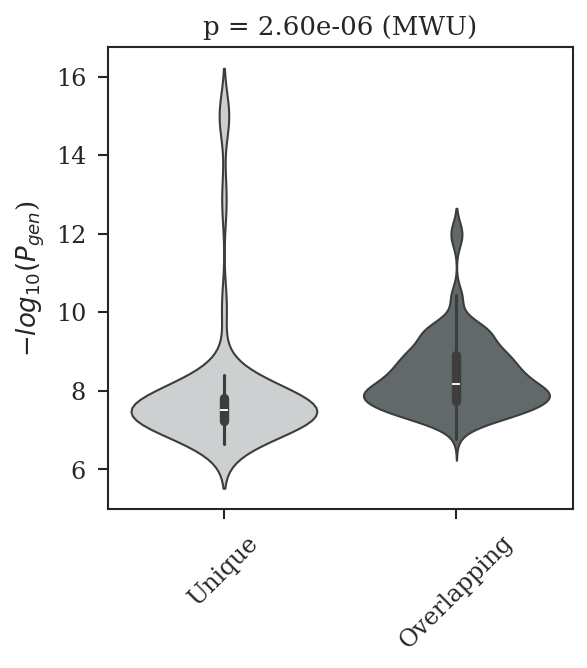

In [22]:
fig, ax = plt.subplots(dpi=150, figsize=(4,4))

sns.violinplot(data=hla, x='dewitt', y='logpgen', ax=ax, palette=['#ccd1d1', '#616a6b'])
S, p = mannwhitneyu(hla[hla.dewitt==True].logpgen, hla[hla.dewitt==False].logpgen)

ax.set_xlabel('')
ax.set_ylabel(r'$-log_{10}(P_{gen}$)')

ax.set_xticklabels(['Unique', 'Overlapping'], rotation=45)
ax.set_title(f'p = {p:.2e} (MWU)')
# ax.plot([0,1], [18,18], color='k', linestyle='-')

fig.savefig('./phd/repositories/sne_manuscript/fig/dewitt_ovl_pgen.png', dpi=500, bbox_inches='tight', format='png')